<a href="https://colab.research.google.com/github/KeerthanaSistla/Sem6DeepLearning/blob/main/DLExternal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. CNN on MNIST Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# CNN Model
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train,y_train,epochs=5)

loss,acc = model.evaluate(x_test,y_test)

print("Accuracy:",acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.9603 - loss: 0.1299
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9866 - loss: 0.0421
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9907 - loss: 0.0301
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9933 - loss: 0.0204
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9947 - loss: 0.0164
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9906 - loss: 0.0296
Accuracy: 0.9905999898910522


#2. MLP using Types of GD for XOR

In [ ]:
import tensorflow as tf
import numpy as np

# XOR Dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

def create_model():

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(4, activation='sigmoid', input_shape=(2,)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    return model

optimizers = {

    'BGD': (tf.keras.optimizers.SGD(0.1),4),

    'SGD': (tf.keras.optimizers.SGD(0.1),1),

    'MiniBatchGD': (tf.keras.optimizers.SGD(0.1),2),

    'Momentum': (
        tf.keras.optimizers.SGD(
            learning_rate=0.1,
            momentum=0.9
        ),1
    ),

    'Nesterov': (
        tf.keras.optimizers.SGD(
            learning_rate=0.1,
            momentum=0.9,
            nesterov=True
        ),1
    ),

    'Adagrad': (
        tf.keras.optimizers.Adagrad(0.1),1
    ),

    'RMSProp': (
        tf.keras.optimizers.RMSprop(0.01),1
    ),

    'Adadelta': (
        tf.keras.optimizers.Adadelta(1.0),1
    ),

    'Adam': (
        tf.keras.optimizers.Adam(0.01),1
    )
}

for name,(optimizer,batch_size) in optimizers.items():

    print("\nOptimizer:",name)

    model = create_model()

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X,
        y,
        epochs=500,
        batch_size=batch_size,
        verbose=0
    )

    pred = model.predict(X)

    print(np.round(pred))


Optimizer: BGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
[[0.]
 [1.]
 [1.]
 [1.]]

Optimizer: SGD
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
[[0.]
 [1.]
 [1.]
 [1.]]

Optimizer: MiniBatchGD
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
[[0.]
 [0.]
 [1.]
 [1.]]

Optimizer: Momentum
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
[[0.]
 [1.]
 [1.]
 [0.]]

Optimizer: Nesterov


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
[[0.]
 [1.]
 [1.]
 [0.]]

Optimizer: Adagrad


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
[[0.]
 [1.]
 [1.]
 [1.]]

Optimizer: RMSProp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
[[0.]
 [1.]
 [1.]
 [0.]]

Optimizer: Adadelta
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
[[0.]
 [1.]
 [0.]
 [0.]]

Optimizer: Adam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
[[0.]
 [1.]
 [1.]
 [1.]]


#3. Simple Perceptron

In [ ]:
import numpy as np

x = np.array([1,0])
w = np.array([0.5,0.5])
b = -0.2

# Feed Forward
net = np.dot(x,w) + b

# Step Function
def step(z):
    if z >= 0:
        return 1
    return 0

# Sigmoid Function
def sigmoid(z):
    return 1/(1+np.exp(-z))

print("Feed Forward:",net)
print("Step Output:",step(net))
print("Sigmoid Output:",sigmoid(net))

Feed Forward: 0.3
Step Output: 1
Sigmoid Output: 0.574442516811659


#4. AND and OR using Single Perceptron

In [6]:
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

def step_fn(y):
    return 1 if y >= 0 else 0

print("AND Gate")

w = np.array([1, 1])
b = -1.5

for x in X:
    y = np.dot(x, w) + b
    print(x, "->", step_fn(y))

print("\nOR Gate")

w = np.array([1, 1])
b = -0.5

for x in X:
    y = np.dot(x, w) + b
    print(x, "->", step_fn(y))

AND Gate
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

OR Gate
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


#5. MLP using Gradient Descent

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5288 - loss: 0.7478 - val_accuracy: 0.5350 - val_loss: 0.7407
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6125 - loss: 0.6921 - val_accuracy: 0.5950 - val_loss: 0.6918
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7100 - loss: 0.6589 - val_accuracy: 0.7150 - val_loss: 0.6577
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8100 - loss: 0.6340 - val_accuracy: 0.8250 - val_loss: 0.6327
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8625 - loss: 0.6145 - val_accuracy: 0.8650 - val_loss: 0.6126
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8838 - loss: 0.5970 - val_accuracy: 0.8850 - val_loss: 0.5937
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8825 - loss: 0.5802 - val_accuracy: 0.8850 - val_loss: 0.5750
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8838 - loss: 0.5637 - val_accuracy: 0.8950 

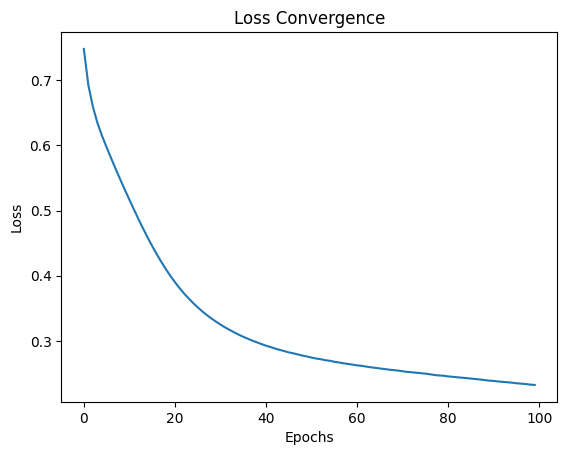

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X,y = make_moons(n_samples=1000,noise=0.2)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2
)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test,y_test)
)

plt.plot(history.history['loss'])
plt.title("Loss Convergence")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

#6. Regularization Techniques

In [11]:
import tensorflow as tf
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# Dataset
X, y = make_moons(n_samples=1000, noise=0.2)

# Adding Noise
X = X + np.random.normal(0, 0.1, X.shape)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

# Function to create MLP model
def create_model():

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5
)

# Ensemble Models
model1 = create_model()
model2 = create_model()
model3 = create_model()

# Train Models
model1.fit(X_train, y_train,
           epochs=50,
           validation_data=(X_test, y_test),
           callbacks=[early_stop],
           verbose=0)

model2.fit(X_train, y_train,
           epochs=50,
           validation_data=(X_test, y_test),
           callbacks=[early_stop],
           verbose=0)

model3.fit(X_train, y_train,
           epochs=50,
           validation_data=(X_test, y_test),
           callbacks=[early_stop],
           verbose=0)

# Predictions
p1 = model1.predict(X_test)
p2 = model2.predict(X_test)
p3 = model3.predict(X_test)

# Ensemble Voting
final = np.round((p1 + p2 + p3) / 3)

# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, final)

print("Ensemble Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Ensemble Accuracy: 0.915


#7. XOR and XNOR using Single Perceptron

In [5]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

X = np.array([[0,0],[0,1],[1,0],[1,1]])

w = [1, 1]
b = -0.5

print("Trying XOR using Single Perceptron\n")

for x in X:
    z = np.dot(x, w) + b
    y = step(net)
    print(x, "->", y)

print("\nActual XOR Output")

for x in X:
    xor = x[0] ^ x[1]
    print(x, "->", xor)


print("\nTrying XNOR using Single Perceptron\n")
for x in X:
    xor = int(not(x[0] ^ x[1]))
    print(x, "->", xor)

print("\nConclusion:")
print("XOR and XNOR cannot be implemented")
print("using a single perceptron")
print("because they are not linearly separable.")

Trying XOR using Single Perceptron

[0 0] -> 1
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1

Actual XOR Output
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0

Trying XNOR using Single Perceptron

[0 0] -> 1
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

Conclusion:
XOR and XNOR cannot be implemented
using a single perceptron
because they are not linearly separable.


#Easy but long

#8. Implement the Perceptron Learning Algorithm and study the effect of weight updates on convergence for a binary decision problem such as determining whether a user would like to watch a movie.

In [7]:
import numpy as np

X = np.array([
    [1,1,1,0.9],
    [1,0,0,0.7],
    [0,1,0,0.6],
    [0,0,1,0.4],
    [0,0,0,0.3]
])

y = np.array([1,1,0,0,0])

print("i) MP Perceptron\n")
for i, x in enumerate(X):
    if sum(x) >= 1.5:
        prediction = 1
    else:
        prediction = 0

    print(f"Movie {i+1}")
    print("Input:", x)
    print("Actual:", y[i])
    print("Predicted:", prediction)
    print()

print("\nii) Perceptron with Weights\n")

weights = np.zeros(4)

lr = 0.1

epochs = 5

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}")

    for i in range(len(X)):

        z = np.dot(X[i], weights)

        prediction = 1 if z >= 0.5 else 0

        error = y[i] - prediction

        weights = weights + lr * error * X[i]

        print(f"Input: {X[i]}")
        print(f"Prediction: {prediction}")
        print(f"Actual: {y[i]}")
        print(f"Error: {error}")
        print(f"Updated Weights: {weights}")
        print()

print("\nFinal Weights:")
print(weights)

print("\niii) Perceptron with Weights and Bias")

weights = np.zeros(4)
bias = 0
lr = 0.1
epochs = 5

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}")

    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        prediction = 1 if z >= 0.5 else 0
        error = y[i] - prediction
        weights = weights + lr * error * X[i]
        bias = bias + lr * error
        print(f"Input: {X[i]}")
        print(f"Prediction: {prediction}")
        print(f"Actual: {y[i]}")
        print(f"Error: {error}")
        print(f"Updated Weights: {weights}")
        print(f"Updated Bias: {bias}")
        print()

print("\nFinal Weights:")
print(weights)

print("Final Bias:")
print(bias)

print("Testing Sample Movie\n")

sample = np.array([1,1,0,0.85])

z = np.dot(sample, weights) + bias

prediction = 1 if z >= 0.5 else 0

print("Sample Movie:", sample)

if prediction == 1:
    print("Perceptron Prediction: LIKE")
else:
    print("Perceptron Prediction: DISLIKE")

i) MP Perceptron

Movie 1
Input: [1.  1.  1.  0.9]
Actual: 1
Predicted: 1

Movie 2
Input: [1.  0.  0.  0.7]
Actual: 1
Predicted: 1

Movie 3
Input: [0.  1.  0.  0.6]
Actual: 0
Predicted: 1

Movie 4
Input: [0.  0.  1.  0.4]
Actual: 0
Predicted: 0

Movie 5
Input: [0.  0.  0.  0.3]
Actual: 0
Predicted: 0


ii) Perceptron with Weights


Epoch 1
Input: [1.  1.  1.  0.9]
Prediction: 0
Actual: 1
Error: 1
Updated Weights: [0.1  0.1  0.1  0.09]

Input: [1.  0.  0.  0.7]
Prediction: 0
Actual: 1
Error: 1
Updated Weights: [0.2  0.1  0.1  0.16]

Input: [0.  1.  0.  0.6]
Prediction: 0
Actual: 0
Error: 0
Updated Weights: [0.2  0.1  0.1  0.16]

Input: [0.  0.  1.  0.4]
Prediction: 0
Actual: 0
Error: 0
Updated Weights: [0.2  0.1  0.1  0.16]

Input: [0.  0.  0.  0.3]
Prediction: 0
Actual: 0
Error: 0
Updated Weights: [0.2  0.1  0.1  0.16]


Epoch 2
Input: [1.  1.  1.  0.9]
Prediction: 1
Actual: 1
Error: 0
Updated Weights: [0.2  0.1  0.1  0.16]

Input: [1.  0.  0.  0.7]
Prediction: 0
Actual: 1
Error: 1
Upd

#9. Demonstrate that the thresholding logic used by perceptron is very harsh.

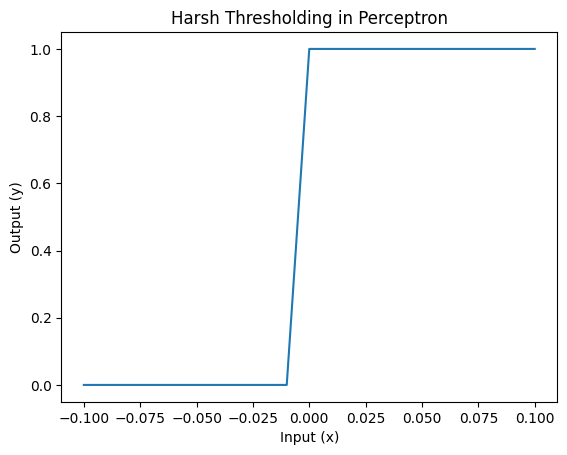

In [14]:
import matplotlib.pyplot as plt

x = [-0.1, -0.01, 0, 0.01, 0.1]

y = []
for i in x:
    if i >= 0:
        y.append(1)
    else:
        y.append(0)

plt.plot(x, y)
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.title("Harsh Thresholding in Perceptron")
plt.show()

# 10. Implement MLP varying learning rates, record observations, and plot loss.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


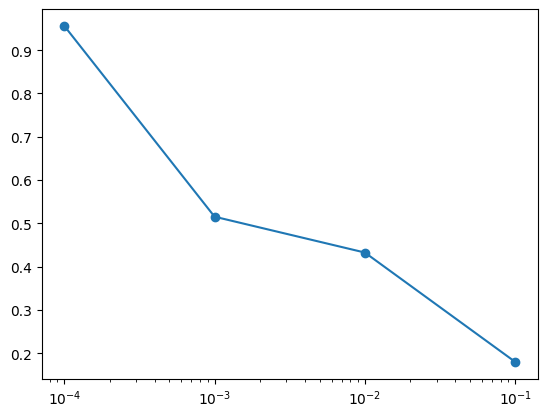

In [29]:
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import log_loss

X, y = make_classification(n_samples=200, n_features=5)
lrs = [0.0001, 0.001, 0.01, 0.1]
losses = []

for lr in lrs:
    model = MLPClassifier(hidden_layer_sizes=(5,), learning_rate_init=lr, max_iter=20)
    model.fit(X, y)
    losses.append(log_loss(y, model.predict_proba(X)))

plt.plot(lrs, losses, marker='o')
plt.xscale('log')
plt.show()

11.Explain the architecture of LeNet and implement it for digit classification.

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Input

(x_train,y_train),(x_test,y_test)=mnist.load_data()

x_train = x_train.reshape(-1,28,28,1) / 255.0
x_test = x_test.reshape(-1,28,28,1) / 255.0

model = tf.keras.Sequential([

    Conv2D(6, (5,5),input_shape=(28,28,1),activation='tanh'),
    AveragePooling2D(pool_size=(2,2)),

    Conv2D(16,(5,5),activation='tanh'),
    AveragePooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(120,activation='tanh'),
    Dense(84,activation='tanh'),
    Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train,y_train,epochs=5)

model.evaluate(x_test,y_test)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9270 - loss: 0.2425
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9727 - loss: 0.0898
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9813 - loss: 0.0615
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9857 - loss: 0.0463
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9876 - loss: 0.0389
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9851 - loss: 0.0468


[0.04682501032948494, 0.9850999712944031]

#12. Denoising Autoencoder

In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(784, activation='sigmoid'),
    tf.keras.layers.Reshape((28, 28))
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

model.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test_noisy, x_test)
)

model.evaluate(x_test_noisy, x_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2371 - val_loss: 0.1695
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1528 - val_loss: 0.1389
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1339 - val_loss: 0.1275
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1254 - val_loss: 0.1216
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1206 - val_loss: 0.1180
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1180


0.11804548650979996

#13. AlexNet

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Lambda

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = tf.image.resize(tf.expand_dims(x_train, -1), (227, 227))
x_test = tf.image.resize(tf.expand_dims(x_test, -1), (227, 227))

x_train = tf.repeat(x_train, 3, axis=-1)
x_test = tf.repeat(x_test, 3, axis=-1)

model = Sequential([
    Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(227, 227, 3)),
    MaxPooling2D((3, 3), strides=2),

    Conv2D(256, (5, 5), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=2),

    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=2),

    Flatten(),

    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

model.evaluate(x_test, y_test)

#14. RNN Next Character Prediction

In [3]:
import numpy as np
import tensorflow as tf

text = "hello world"

chars = sorted(list(set(text)))
char2idx = {c:i for i,c in enumerate(chars)}
idx2char = {i:c for i,c in enumerate(chars)}

X = []
y = []

for i in range(len(text) - 1):
    X.append(char2idx[text[i]])
    y.append(char2idx[text[i+1]])

X = np.array(X)
y = np.array(y)

X = X.reshape(-1, 1)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(len(chars), 8),
    tf.keras.layers.SimpleRNN(16),
    tf.keras.layers.Dense(len(chars), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)

model.fit(X, y, epochs=100, verbose=0)

test = np.array([char2idx['h']]).reshape(1, 1)

pred = model.predict(test, verbose=0)
print("Predicted:", idx2char[np.argmax(pred)])

Predicted: e


#15. Implement Under and over complete Autoencoder and evaluate reconstruction.

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2435
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1446
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1194
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


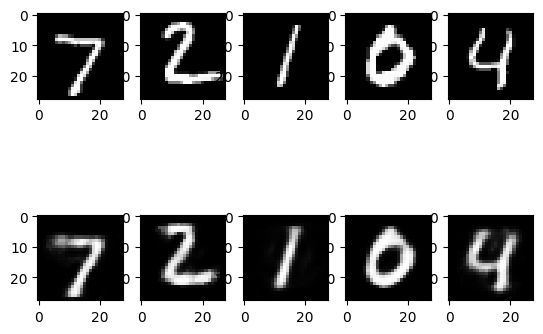

Overcomplete Autoencoder
Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1372
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0749
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0690
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


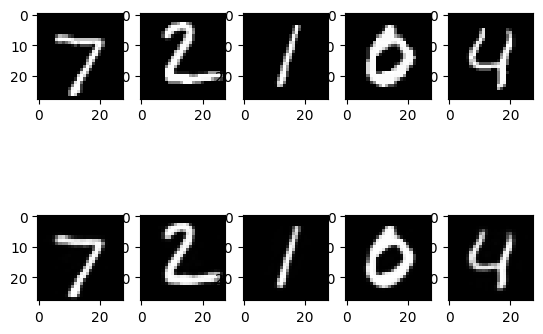

In [4]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = datasets.mnist.load_data()
x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(input_img, decoded)
model.compile(optimizer='adam', loss='binary_crossentropy')

model.fit(x_train, x_train, epochs=3, batch_size=256)

decoded_imgs = model.predict(x_test[:5])

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')

plt.show()

print("Overcomplete Autoencoder")

import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = datasets.mnist.load_data()
x_train = x_train/255.0
x_test = x_test/255.0
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

input_img = Input(shape=(784,))
encoded = Dense(1024, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(input_img, decoded)
model.compile(optimizer='adam', loss='binary_crossentropy')

model.fit(x_train, x_train, epochs=3, batch_size=256)

decoded_imgs = model.predict(x_test[:5])

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')

plt.show()

#16. Implement BERT model for text classification.

In [1]:
!pip install -q transformers

from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

text = "I love this product!"

result = classifier(text)[0]

label = result['label']
binary_output = 1 if label == "POSITIVE" else 0

print("Text:", text)
print("Model Output:", result)
print("Binary Sentiment (1=Positive, 0=Negative):", binary_output)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Text: I love this product!
Model Output: {'label': 'POSITIVE', 'score': 0.9998855590820312}
Binary Sentiment (1=Positive, 0=Negative): 1


#17. Implement GAN on MNIST dataset.

In [5]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape, Flatten
from tensorflow.keras.optimizers import Adam

(X_train, _), _ = mnist.load_data()
X_train = (X_train - 127.5) / 127.5  # Scale to [-1, 1]
X_train = X_train.reshape(-1, 784)

opt = Adam(0.0002, 0.5)

def build_generator():
    model = Sequential([
        Dense(128, input_dim=100),
        LeakyReLU(0.2),
        Dense(784, activation='tanh'),
    ])
    return model

def build_discriminator():
    model = Sequential([
        Dense(128, input_shape=(784,)),
        LeakyReLU(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

generator = build_generator()
discriminator = build_discriminator()

noise = np.random.normal(0, 1, (128, 100))
fake_images = generator.predict(noise)

real_images = X_train[np.random.randint(0, X_train.shape[0], 128)]

real_labels = np.ones((128, 1))
fake_labels = np.zeros((128, 1))

d_loss_real = discriminator.train_on_batch(real_images, real_labels)
d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

print("Discriminator accuracy on real:", d_loss_real[1]*100)
print("Discriminator accuracy on fake:", d_loss_fake[1]*100)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 
Discriminator accuracy on real: 87.5
Discriminator accuracy on fake: 60.9375


#18. Implement LSTM and GRU architectures to deal with long term dependencies.

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense

vocab = {'the':0, 'sun':1, 'is':2, 'shining':3, 'bright':4, 'today':5}
idx2word = {i:w for w,i in vocab.items()}
vocab_size = len(vocab)

X = np.array([[0, 1, 2, 3]])
y = np.array([4])

# LSTM model
lstm_model = Sequential([
    Embedding(vocab_size, 10, input_length=4),
    LSTM(32),
    Dense(vocab_size, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
lstm_model.fit(X, y, epochs=200, verbose=0)

# GRU model
gru_model = Sequential([
    Embedding(vocab_size, 10, input_length=4),
    GRU(32),
    Dense(vocab_size, activation='softmax')
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
gru_model.fit(X, y, epochs=200, verbose=0)

# Prediction
test = np.array([[0, 1, 2, 3]])

lstm_pred = lstm_model.predict(test, verbose=0)
gru_pred = gru_model.predict(test, verbose=0)

print("LSTM:", idx2word[np.argmax(lstm_pred)])
print("GRU :", idx2word[np.argmax(gru_pred)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM: bright
GRU : bright


#19. Implement Sparse and Contractive Autoencoder.

Training Sparse AE
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.4166 - val_loss: 0.2698
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2660 - val_loss: 0.2641
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2638 - val_loss: 0.2632
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2633 - val_loss: 0.2629
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2631 - val_loss: 0.2628
Training Contractive AE
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.3072 - val_loss: 0.1939
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1804 - val_loss: 0.1699
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1667 - val_loss: 0.1616
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1602 - val_loss: 0.1565
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1562 - val_loss: 0.1530


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


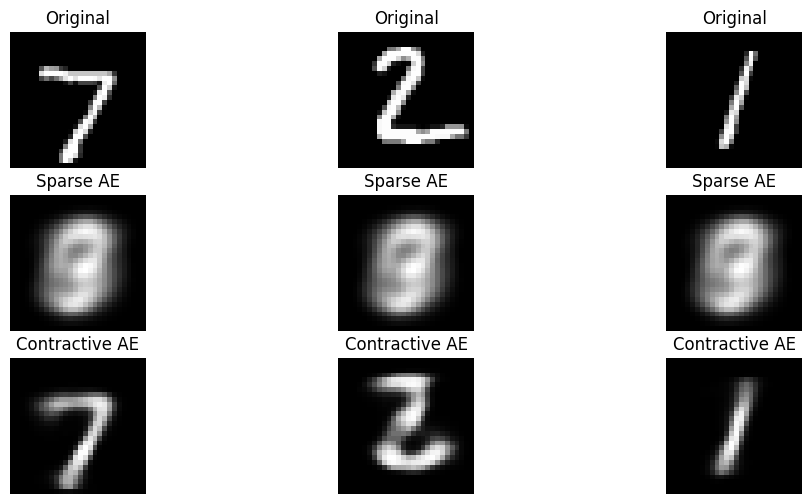

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras import regularizers

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

input_layer = Input(shape=(784,))

encoded = Dense(
    128,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-4)
)(input_layer)

latent = Dense(
    32,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-4)
)(encoded)

decoded = Dense(128, activation='relu')(latent)
output_layer = Dense(784, activation='sigmoid')(decoded)

sparse_ae = Model(input_layer, output_layer)

sparse_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Training Sparse AE")

sparse_ae.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

input_layer2 = Input(shape=(784,))

encoded2 = Dense(
    128,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(0.001)
)(input_layer2)

latent2 = Dense(
    32,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(0.001)
)(encoded2)

decoded2 = Dense(128, activation='relu')(latent2)
output_layer2 = Dense(784, activation='sigmoid')(decoded2)

contractive_ae = Model(input_layer2, output_layer2)

contractive_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Training Contractive AE")

contractive_ae.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

sparse_output = sparse_ae.predict(x_test)
contractive_output = contractive_ae.predict(x_test)

plt.figure(figsize=(12,6))

for i in range(3):
    # Original
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Sparse AE
    plt.subplot(3, 3, i + 4)
    plt.imshow(sparse_output[i].reshape(28,28), cmap='gray')
    plt.title("Sparse AE")
    plt.axis("off")

    # Contractive AE
    plt.subplot(3, 3, i + 7)
    plt.imshow(contractive_output[i].reshape(28,28), cmap='gray')
    plt.title("Contractive AE")
    plt.axis("off")

plt.show()

#20. Implement Transformer model

In [9]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        input_dim=1000,
        output_dim=64
    ),

    tf.keras.layers.MultiHeadAttention(
        num_heads=2,
        key_dim=64
    ),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(64,activation='relu'),

    tf.keras.layers.Dense(2,activation='softmax')
])

print(model.summary())

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_head_attention            │ ?                      │   0 (unbuilt) │
│ (MultiHeadAttention)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
